# 38. tSZ power spectrum at $z\sim0$, $1$, $2$ (L2p8_m9 lc0)

For each target redshift we **sum the per-shell Compton-$y$ maps** in that bin,
then measure $D_\ell$ of the combined map and compare to **hmfast** (**nb05** convention:
Arnaud A10 GNFW, $B=1.0$, D3A cosmology).

| region | shells summed | approximate $z$ range |
|--------|---------------|------------------------|
| $z\sim0$ | 0+1+2+3+4 | 0.001 – 0.25 |
| $z\sim1$ | 17+18+19+20+21 | 0.85 – 1.10 |
| $z\sim2$ | 37+38+39+40+41 | 1.85 – 2.10 |

Pipeline (nb05): build $y_\mathrm{sum}=\sum_i y_i$, subtract monopole,
`anafast`, deconvolve pixel window, $/f_\mathrm{sky}$.

Theory (nb05): explicit A10 GNFW parameters, $1h+2h$ Limber integral with
`z = np.geomspace(zlo, zhi, n_z_bins)` over each bin's $[z_\mathrm{inner}, z_\mathrm{outer}]$.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")

REPO = Path("/scratch/scratch-lxu/flamingo_repo")
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "scripts"))

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import jax.numpy as jnp

from flamingo.catalogue import D3A_COSMOLOGY
from flamingo_shells import shell_bounds, shell_snapshot_table
from hmfast.halos import HaloModel
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

MAP_DIR = Path("/rds/rds-lxu/flamingo/L2p8_m9/lightcone0/healpix_map/snapshots")
MAP_TMPL = MAP_DIR / "comptonY_L2p8_m9_lc0_nside4096_shell{idx}.fits"
FIG_DIR = REPO / "figures/nb38_l2p8_shell_snapshot_tsz_ps"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    (r"$z\sim0$", list(range(0, 5))),
    (r"$z\sim1$", list(range(17, 22))),
    (r"$z\sim2$", list(range(37, 42))),
]
LMAX = 6000
# Arnaud et al. (2010) A10 GNFW — same as notebook 05
A10_B1 = dict(P0=8.403, c500=1.177, gamma=0.3081, alpha=1.0510, beta=5.4905)

In [2]:
def load_shell(idx):
    path = Path(str(MAP_TMPL).format(idx=idx))
    if not path.exists():
        raise FileNotFoundError(path)
    return hp.read_map(str(path), dtype=np.float64)


def sum_shells(indices):
    """Add per-shell Compton-y maps (same NSIDE, RING)."""
    y = None
    for idx in indices:
        m = load_shell(idx)
        y = m if y is None else y + m
    return y


def measure_dl_map(y, lmax=LMAX):
    nside = hp.npix2nside(y.size)
    fsky = float(np.mean(y != 0.0))
    cl = hp.anafast(y - y.mean(), lmax=lmax, iter=0)
    ell = np.arange(cl.size)
    cl = cl / (hp.pixwin(nside, lmax=lmax) ** 2 * fsky)
    return ell, ell * (ell + 1) / (2 * np.pi) * cl


def log_bin(ell, dl, lmin=10, lmax=LMAX, nbin=30):
    edges = np.logspace(np.log10(lmin), np.log10(lmax), nbin + 1)
    idx = np.digitize(ell, edges) - 1
    lb, db = [], []
    for b in range(nbin):
        sel = (idx == b) & (ell >= lmin)
        if sel.any():
            lb.append(ell[sel].mean())
            db.append(dl[sel].mean())
    return np.array(lb), np.array(db)


hm = HaloModel(cosmology=D3A_COSMOLOGY)
ell_th = jnp.logspace(1.0, np.log10(LMAX), 40)
m_grid = jnp.logspace(11.0, 15.5, 60)   # nb05
pref = np.asarray(ell_th) * (np.asarray(ell_th) + 1) / (2 * np.pi)

N_Z_BINS = 60  # nb05


def theory_dl(zlo, zhi, n_z_bins=N_Z_BINS):
    """tSZ D_l from hmfast (nb05): A10 GNFW B=1, log-spaced z over [zlo, zhi]."""
    z = jnp.geomspace(max(zlo, 0.001), zhi, n_z_bins)
    profile = GNFWPressureProfile(**A10_B1, B=1.0)
    tracer = tSZTracer(profile=profile)
    cl1 = np.asarray(hm.cl_1h(tracer, tracer, l=ell_th, m=m_grid, z=z))
    cl2 = np.asarray(hm.cl_2h(tracer, tracer, l=ell_th, m=m_grid, z=z))
    return pref * (cl1 + cl2)


def region_z_range(indices):
    zlo = shell_bounds(indices[0])[0]
    zhi = shell_bounds(indices[-1])[1]
    return zlo, zhi


def shells_label(indices):
    return "+".join(str(i) for i in indices)

In [3]:
results = []
for zlabel, indices in REGIONS:
    zlo, zhi = region_z_range(indices)
    y_sum = sum_shells(indices)
    ell, dl = measure_dl_map(y_sum)
    ellb, dlb = log_bin(ell, dl)
    dth = theory_dl(zlo, zhi)
    results.append(dict(
        zlabel=zlabel, indices=indices, zlo=zlo, zhi=zhi,
        y_sum=y_sum, ellb=ellb, dlb=dlb, dth=dth,
    ))
    print(f"{zlabel}  shells {shells_label(indices)}  z=[{zlo:.3f},{zhi:.3f}]")
    print(f"  sum(y)={y_sum.sum():.4f}  D_3000 meas={np.interp(3000, ell, dl):.2e}  "
          f"theory={np.interp(3000, np.asarray(ell_th), dth):.2e}")

$z\sim0$  shells 0+1+2+3+4  z=[0.001,0.250]
  sum(y)=49.1951  D_3000 meas=1.66e-13  theory=2.26e-13
$z\sim1$  shells 17+18+19+20+21  z=[0.850,1.100]
  sum(y)=35.7338  D_3000 meas=1.96e-13  theory=1.62e-13
$z\sim2$  shells 37+38+39+40+41  z=[1.850,2.100]
  sum(y)=14.4990  D_3000 meas=1.58e-14  theory=8.73e-15


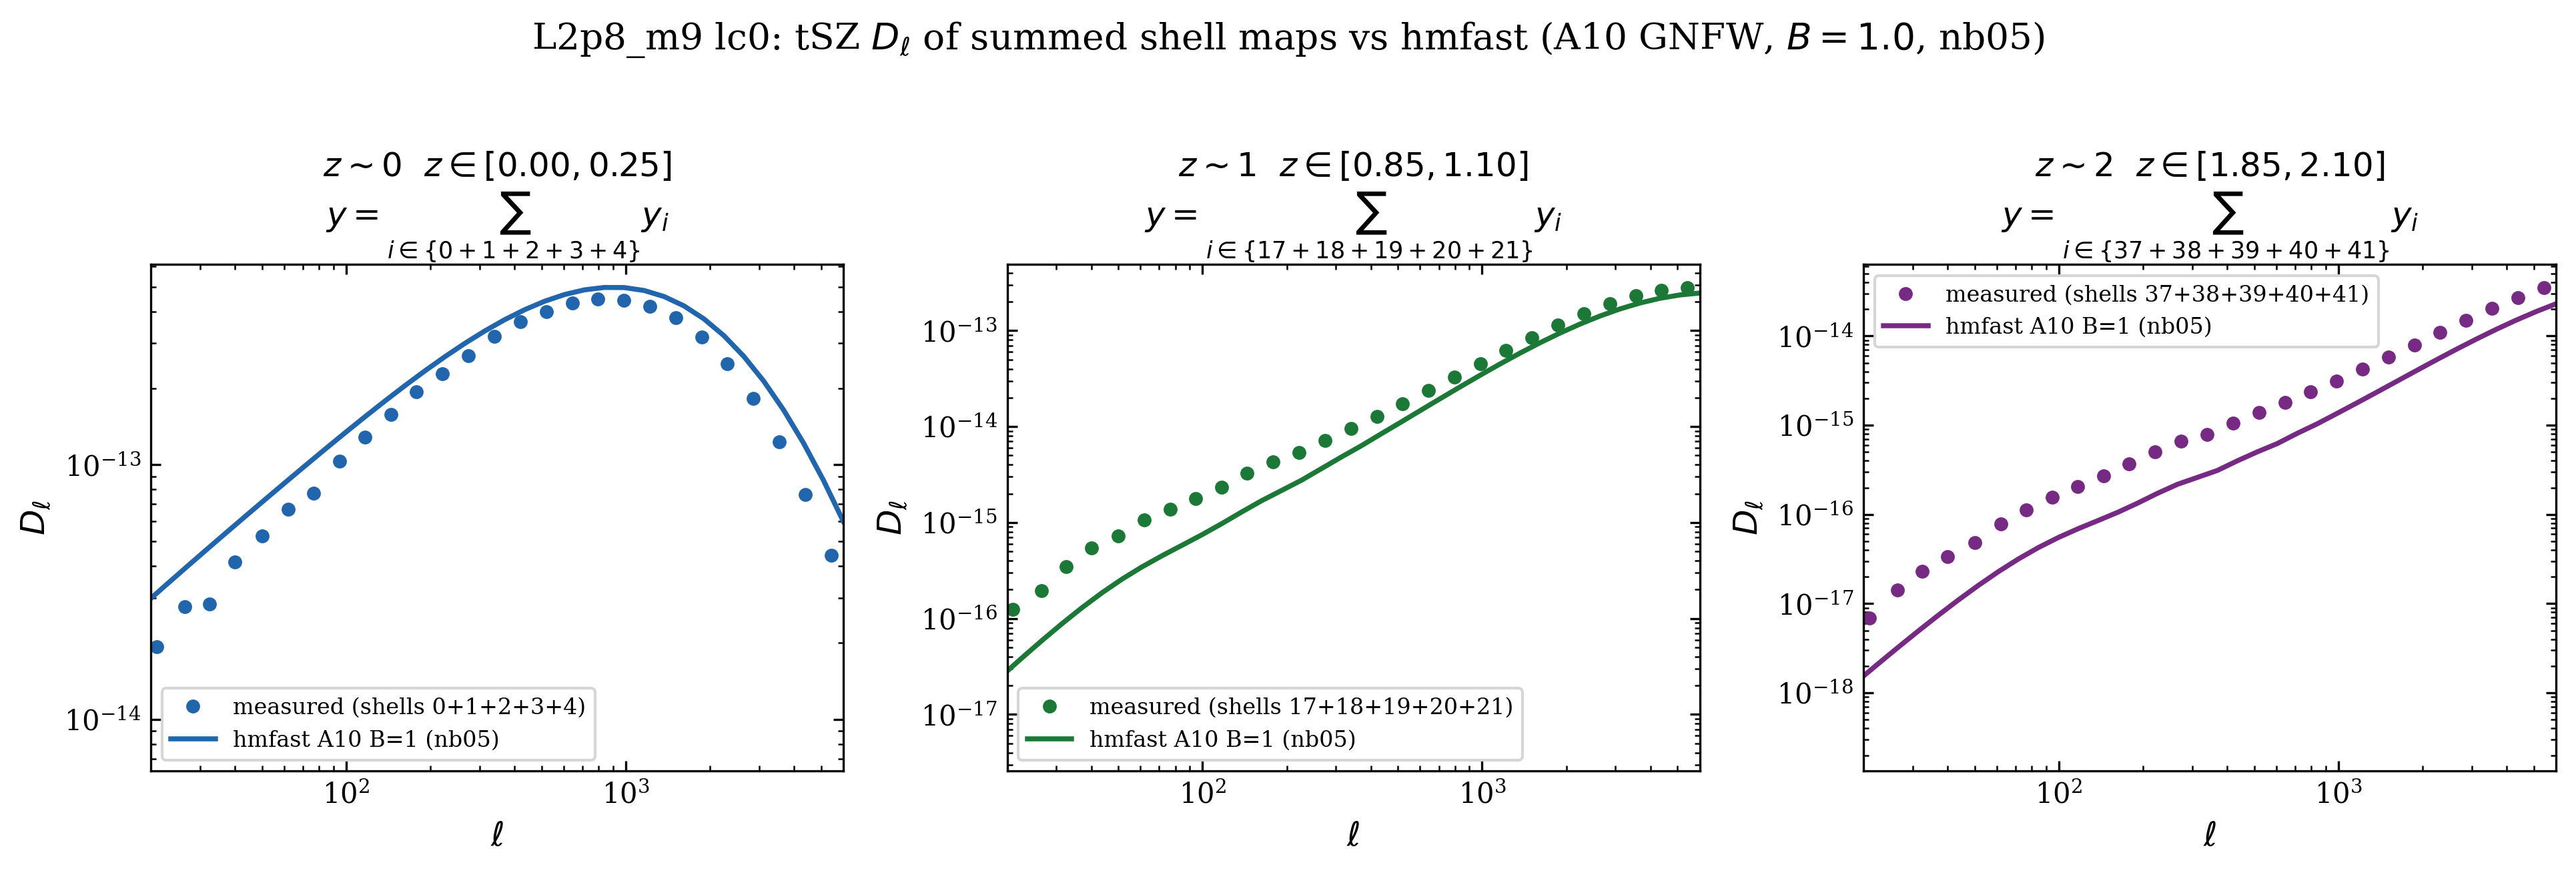

Saved to /scratch/scratch-lxu/flamingo_repo/figures/nb38_l2p8_shell_snapshot_tsz_ps


In [4]:
colors = ["#2166ac", "#1b7837", "#762a83"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True)

for ax, r, col in zip(axes, results, colors):
    shells_str = shells_label(r["indices"])
    ax.plot(r["ellb"], r["dlb"], "o", ms=4, color=col,
            label=fr"measured (shells {shells_str})")
    ax.plot(np.asarray(ell_th), r["dth"], "-", lw=1.8, color=col,
            label="hmfast A10 B=1 (nb05)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(20, LMAX)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$D_\ell$")
    ax.set_title(
        rf"{r['zlabel']}  $z\in[{r['zlo']:.2f},{r['zhi']:.2f}]$"
        "\n"
        rf"$y = \sum_{{i\in \{{{shells_str}\}}}} y_i$"
    )
    ax.legend(fontsize=8)

fig.suptitle(
    r"L2p8_m9 lc0: tSZ $D_\ell$ of summed shell maps vs hmfast (A10 GNFW, $B=1.0$, nb05)",
    y=1.03,
)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"shell_sum_tsz_ps_z012.{ext}", bbox_inches="tight")
plt.show()
print("Saved to", FIG_DIR)

## Full lightcone map ($0 \le z < 3$)

Integrated yang26-rotated Compton-$y$ map (`y_unlensed_L2p8_m9_lc0.fits`, shells 0–59 summed on the portal) vs hmfast over $z \in [0.001, 3.0]$.

full map: y_unlensed_L2p8_m9_lc0.fits
  mean(y)=1.536e-06  sum(y)=309.2523
  D_3000 meas=1.62e-12  theory=1.59e-12


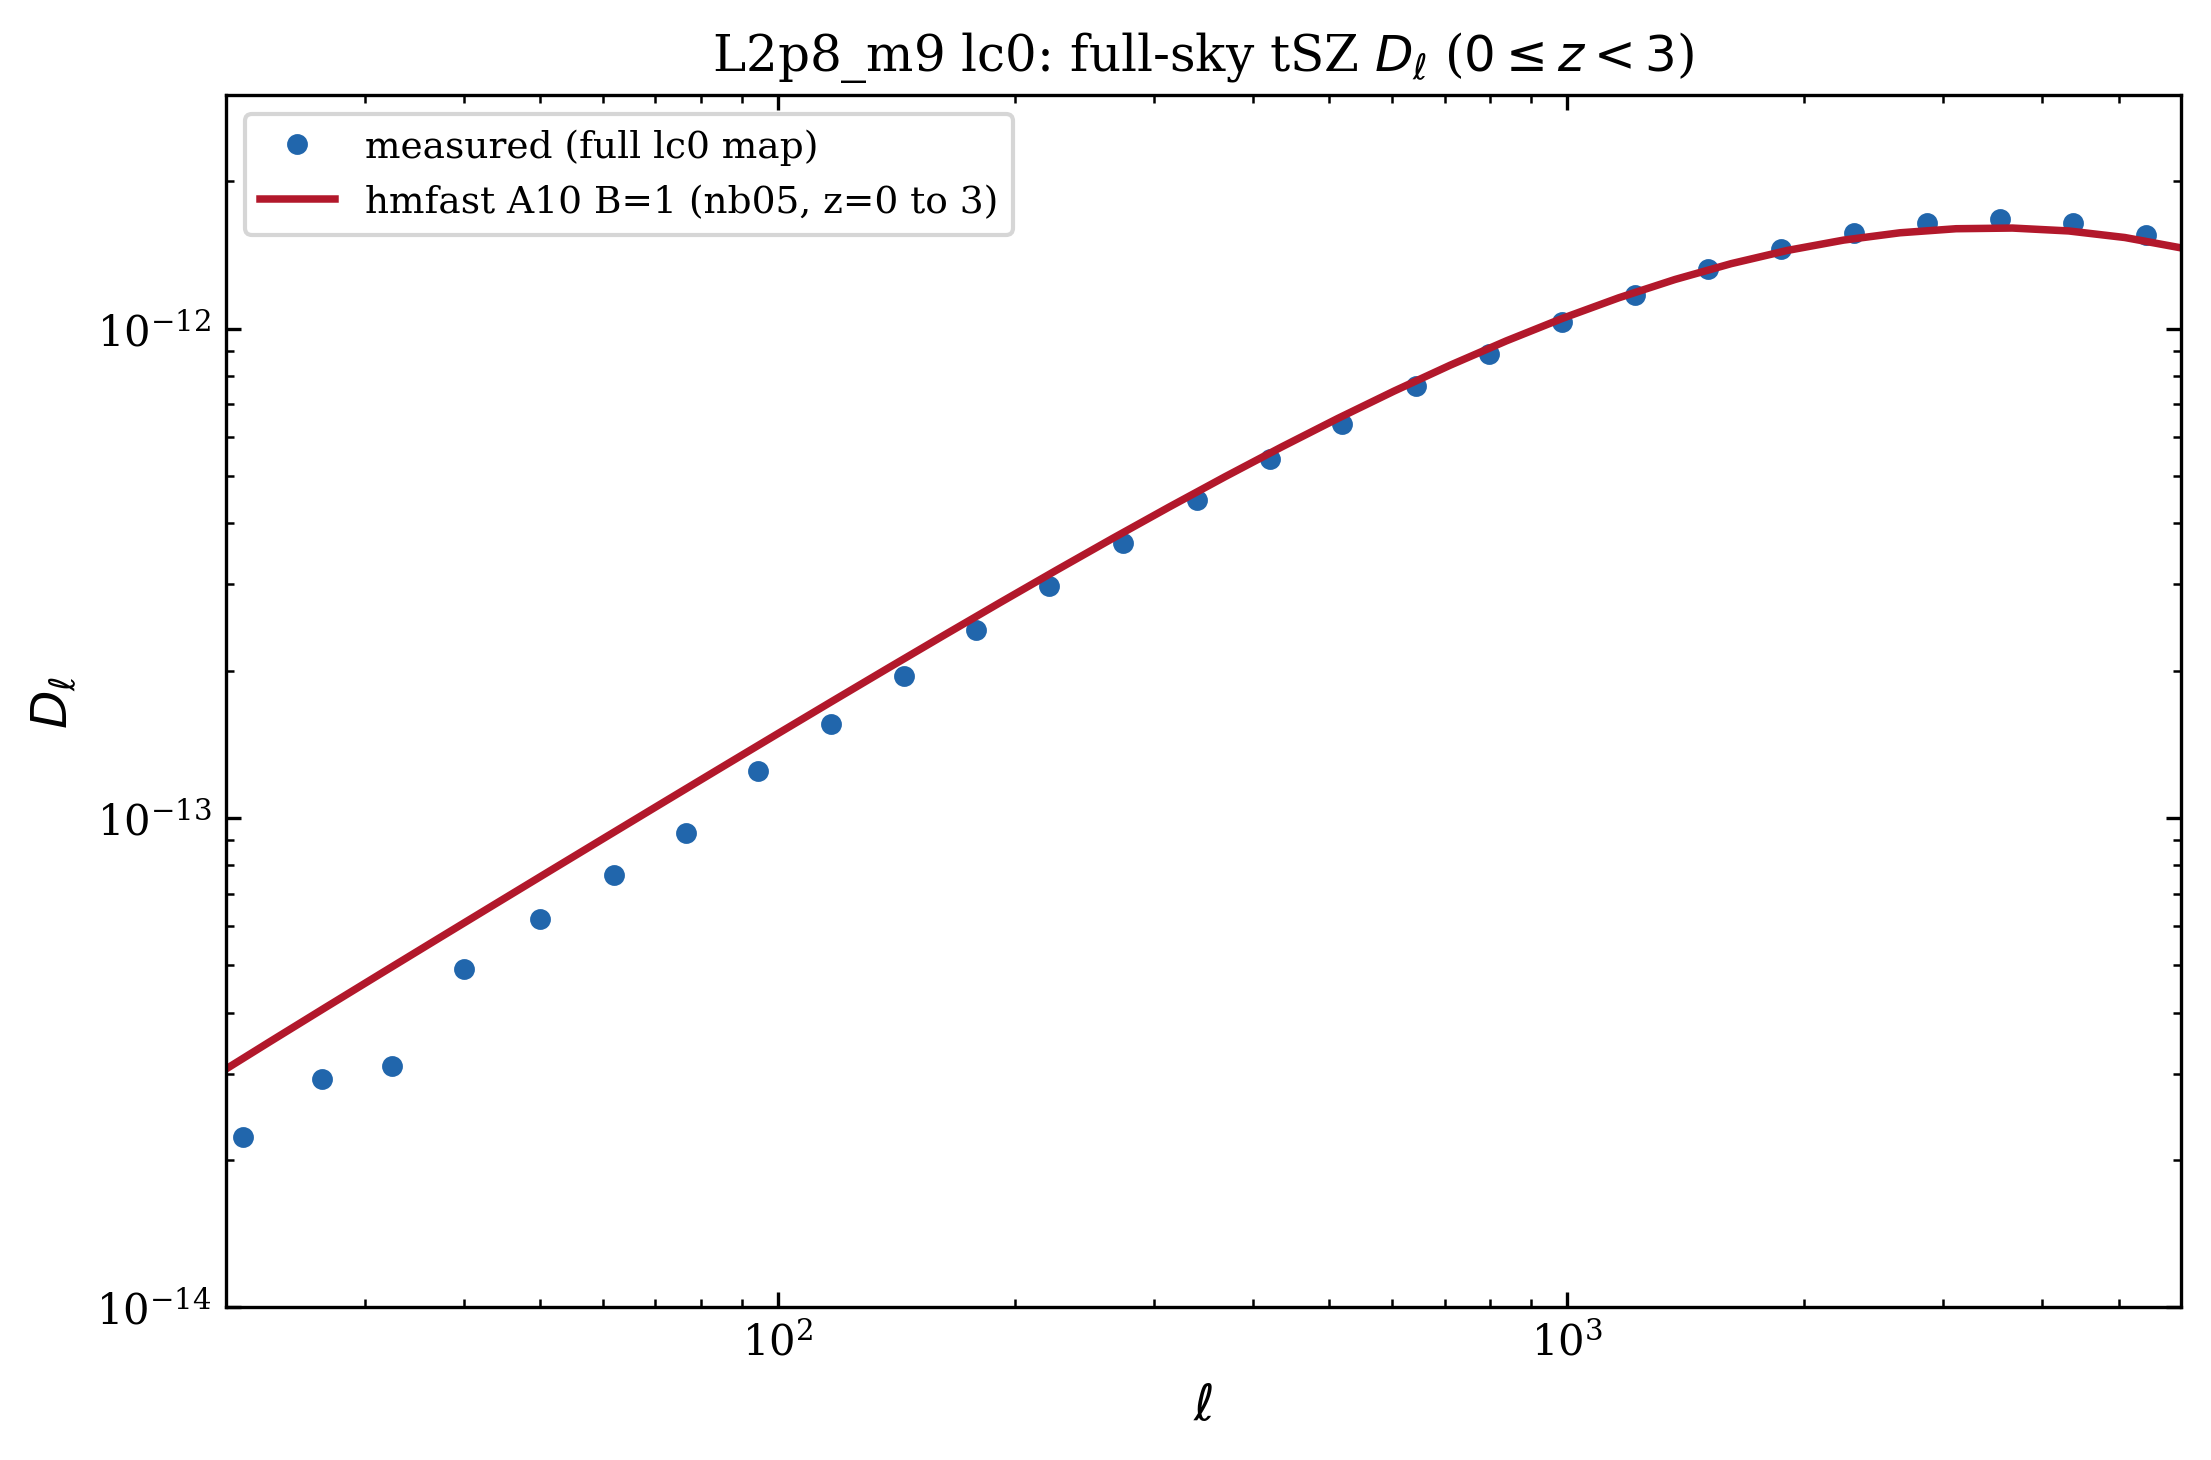

Saved /scratch/scratch-lxu/flamingo_repo/figures/nb38_l2p8_shell_snapshot_tsz_ps/fullsky_tsz_ps_z0to3.png


In [ ]:
FULL_MAP = Path(
    "/rds/rds-lxu/flamingo/L2p8_m9/lightcone0/healpix_map/y_unlensed_L2p8_m9_lc0.fits"
)

y_full = hp.read_map(str(FULL_MAP), dtype=np.float64)
ell_f, dl_f = measure_dl_map(y_full)
ellb_f, dlb_f = log_bin(ell_f, dl_f)
dth_f = theory_dl(0.001, 3.0)

print(f"full map: {FULL_MAP.name}")
print(f"  mean(y)={y_full.mean():.3e}  sum(y)={y_full.sum():.4f}")
print(f"  D_3000 meas={np.interp(3000, ell_f, dl_f):.2e}  "
      f"theory={np.interp(3000, np.asarray(ell_th), dth_f):.2e}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(ellb_f, dlb_f, "o", ms=4, color="#2166ac", label="measured (full lc0 map)")
ax.plot(np.asarray(ell_th), dth_f, "-", lw=1.8, color="#b2182b",
        label="hmfast A10 B=1 (nb05, z=0 to 3)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(20, LMAX)
ax.set_ylim(1e-14, 3e-12)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$D_\ell$")
ax.set_title(r"L2p8_m9 lc0: full-sky tSZ $D_\ell$ ($0 \leq z < 3$)")
ax.legend(fontsize=9)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"fullsky_tsz_ps_z0to3.{ext}", bbox_inches="tight")
plt.show()
print("Saved", FIG_DIR / "fullsky_tsz_ps_z0to3.png")